# 07 – Correlated Manning roughness sampling

Extends the independent Monte Carlo of notebook 01 with a **Gaussian copula** that
allows cross-class correlation.  Three scenarios:

| Scenario | ρ | Interpretation |
|---|---|---|
| A (reference) | 0 | Independent sampling — current 1 000 runs |
| B | 0.5 | Moderate correlation (same environmental driver) |
| C | 1.0 | Perfect correlation — all classes at the same quantile |

The notebook characterises the **sampling**, computes the expected amplification
of spatial-mean CV, and exports the combination CSV files for SFINCS / HEC-RAS.

In [1]:
from pathlib import Path
import sys


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / "pyproject.toml").exists():
            return path
    raise RuntimeError("Could not find HYDRA repo root")


ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

from pyhydra.modeling.hydraulic.sensitivity import (
    generate_manning_combinations,
    generate_manning_combinations_correlated,
    _best_distribution,
)


In [2]:
# ── paths ────────────────────────────────────────────────────────────────────
NB_DIR = ROOT / "notebooks" / "modeling" / "hydraulic" / "manning_sensitivity"
DATA_DIR = NB_DIR / "data"
FIG_DIR = ROOT / "papers" / "besaya_manning_sensitivity" / "figures"

DIST_CSV = DATA_DIR / "manning_roughness_coefficients_dist.csv"
REF_COMBI_CSV = DATA_DIR / "combinaciones_rugosidad.csv"
OUTPUT_BASE = NB_DIR / "generated"

FIG_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_BASE.mkdir(parents=True, exist_ok=True)

LANDUSE_AREAS_HA = {
    "Trees": 25.2, "Dense vegetation": 49.9, "Urban vegetation": 123.4,
    "Infrastructure": 43.0, "Sparse vegetation": 473.0, "Residential": 199.8,
    "Industrial": 120.1, "River": 25.5, "Brushland": 25.7,
}
TOTAL_HA = sum(LANDUSE_AREAS_HA.values())
WEIGHTS = {k: v / TOTAL_HA for k, v in LANDUSE_AREAS_HA.items()}

N_SAMPLES = 1000
SEED = 42


## 1 · Generate correlated combinations

In [3]:
df_ref  = pd.read_csv(REF_COMBI_CSV)          # original 1 000 runs (ρ = 0)
df_rho0 = generate_manning_combinations_correlated(DIST_CSV, N_SAMPLES, rho=0.0, seed=SEED)
df_rho5 = generate_manning_combinations_correlated(DIST_CSV, N_SAMPLES, rho=0.5, seed=SEED)
df_rho1 = generate_manning_combinations_correlated(DIST_CSV, N_SAMPLES, rho=1.0, seed=SEED)

print("Shapes:", df_rho0.shape, df_rho5.shape, df_rho1.shape)
df_rho0.describe().T

Shapes: (1000, 9) (1000, 9) (1000, 9)


## 2 · Area-weighted spatial-mean Manning n̄

In [4]:
def weighted_mean(df):
    """Area-weighted spatial mean Manning n per simulation."""
    w = np.array([WEIGHTS[c] for c in df.columns])
    return df.values @ w

n_bar = {
    "ρ=0 (ref)": weighted_mean(df_ref),
    "ρ=0 (copula)": weighted_mean(df_rho0),
    "ρ=0.5": weighted_mean(df_rho5),
    "ρ=1.0": weighted_mean(df_rho1),
}

print(f"{'Scenario':<18}  {'Mean n̄':>8}  {'SD':>8}  {'CV%':>7}  {'P5':>8}  {'P95':>8}")
print("-" * 64)
for label, vals in n_bar.items():
    p5, p95 = np.percentile(vals, [5, 95])
    cv = 100 * vals.std() / vals.mean()
    print(f"{label:<18}  {vals.mean():8.5f}  {vals.std():8.5f}  {cv:7.2f}%  {p5:8.5f}  {p95:8.5f}")

Scenario             Mean n̄        SD      CV%        P5       P95
----------------------------------------------------------------
ρ=0 (ref)            0.04838   0.00941    19.45%   0.03308   0.06411
ρ=0 (copula)         0.04855   0.00961    19.80%   0.03198   0.06345
ρ=0.5                0.04739   0.01368    28.87%   0.02418   0.06930
ρ=1.0                0.04735   0.01648    34.80%   0.02003   0.07326


## 3 · Theoretical CV amplification

CV at ρ=0: 19.63%  →  ρ=1: 33.56%  (×1.71)


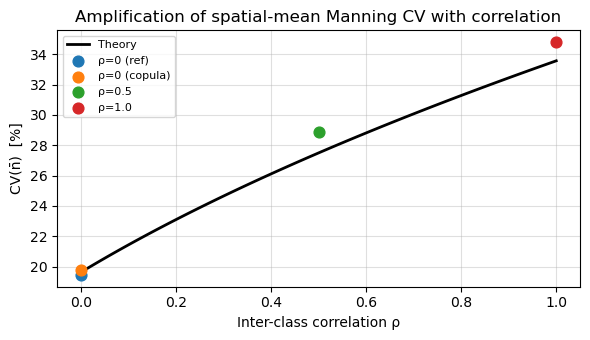

In [5]:
# Fitted marginal sigma per class (std of n)
df_dist = pd.read_csv(DIST_CSV, index_col=0)
class_sigmas = {}  # std of fitted distribution
class_means  = {}
for _, row in df_dist.iterrows():
    if str(row["N"]) == "-999":
        continue
    values = np.array([float(v) for v in str(row["N"]).split(",")])
    dist_name, params = _best_distribution(values)
    dist = getattr(stats, dist_name)
    mu, sigma = dist.stats(*params[:-2], loc=params[-2], scale=params[-1], moments='mv')
    class_means[row["Descripción"]]  = float(mu)
    class_sigmas[row["Descripción"]] = float(np.sqrt(sigma))

w_arr  = np.array([WEIGHTS[k]      for k in class_sigmas])
sig_arr = np.array([class_sigmas[k] for k in class_sigmas])
mu_nbar = (w_arr * np.array([class_means[k] for k in class_sigmas])).sum()

rho_vals = np.linspace(0, 1, 101)
cv_theory = []
for rho in rho_vals:
    # Var[n̄] = Σ_i w_i² σ_i² + ρ Σ_{i≠j} w_i w_j σ_i σ_j
    var_indep = (w_arr**2 * sig_arr**2).sum()
    cross = (w_arr @ sig_arr)**2 - (w_arr**2 * sig_arr**2).sum()
    var_total = var_indep + rho * cross
    cv_theory.append(100 * np.sqrt(var_total) / mu_nbar)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(rho_vals, cv_theory, 'k-', lw=2, label="Theory")
for lbl, vals in n_bar.items():
    rho_num = {"ρ=0 (ref)": 0, "ρ=0 (copula)": 0, "ρ=0.5": 0.5, "ρ=1.0": 1.0}[lbl]
    ax.scatter(rho_num, 100*vals.std()/vals.mean(), zorder=5, s=60, label=lbl)
ax.set_xlabel("Inter-class correlation ρ")
ax.set_ylabel("CV(n̄)  [%]")
ax.set_title("Amplification of spatial-mean Manning CV with correlation")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
print(f"CV at ρ=0: {cv_theory[0]:.2f}%  →  ρ=1: {cv_theory[-1]:.2f}%  (×{cv_theory[-1]/cv_theory[0]:.2f})")

## 4 · Scatter plots — correlation structure across scenarios

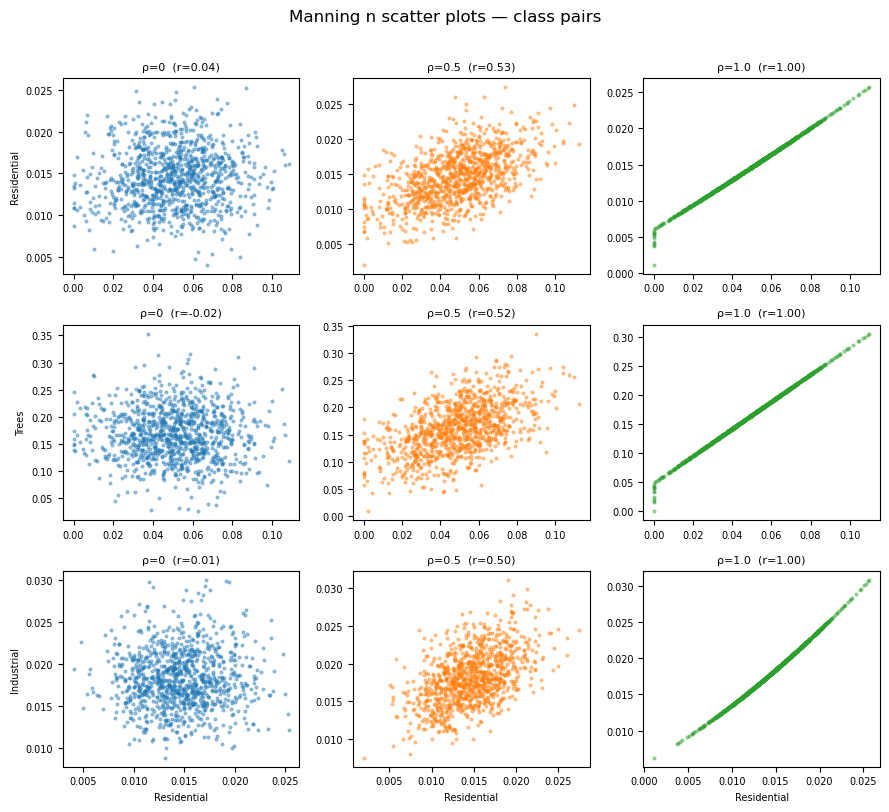

In [6]:
pairs = [
    ("Sparse vegetation", "Residential"),   # dominant classes
    ("Sparse vegetation", "Trees"),
    ("Residential",       "Industrial"),
]

fig, axes = plt.subplots(3, 3, figsize=(9, 8), sharex=False, sharey=False)
scenarios = [(df_rho0, "ρ=0", "C0"), (df_rho5, "ρ=0.5", "C1"), (df_rho1, "ρ=1.0", "C2")]

for row_i, (xa, ya) in enumerate(pairs):
    for col_j, (df_s, lbl, c) in enumerate(scenarios):
        ax = axes[row_i, col_j]
        ax.scatter(df_s[xa], df_s[ya], s=4, alpha=0.4, color=f"C{col_j}")
        r = np.corrcoef(df_s[xa], df_s[ya])[0, 1]
        ax.set_title(f"{lbl}  (r={r:.2f})", fontsize=8)
        if row_i == 2:
            ax.set_xlabel(xa, fontsize=7)
        if col_j == 0:
            ax.set_ylabel(ya, fontsize=7)
        ax.tick_params(labelsize=7)

plt.suptitle("Manning n scatter plots — class pairs", y=1.01)
plt.tight_layout()
plt.show()

## 5 · Distribution of n̄ across scenarios

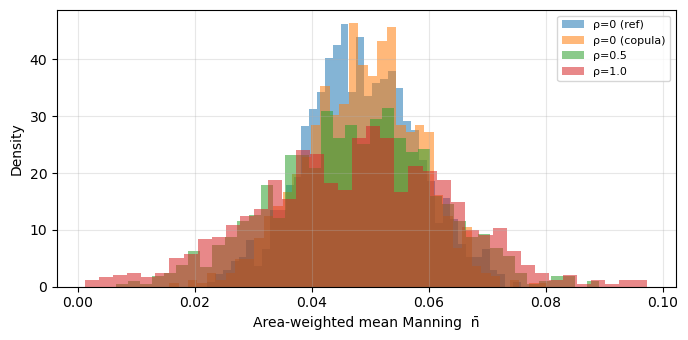

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.5))
colors = ["C0", "C1", "C2", "C3"]
for (lbl, vals), c in zip(n_bar.items(), colors):
    ax.hist(vals, bins=40, density=True, alpha=0.55, color=c, label=lbl)
ax.set_xlabel("Area-weighted mean Manning  n̄")
ax.set_ylabel("Density")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6 · Export combination files for SFINCS / HEC-RAS

Two new directories: `nsim_rugos_rho05/` and `nsim_rugos_rho10/`
Each contains `combinacion_1.csv … combinacion_1000.csv` matching the
existing format used by the pipeline.

In [8]:
# Class code → description mapping (must match manning_mapping.csv)
LANDUSE_CODES = {
    "Trees": 1, "Dense vegetation": 2, "Urban vegetation": 4,
    "Infrastructure": 5, "Sparse vegetation": 6, "Residential": 7,
    "Industrial": 8, "River": 9, "Brushland": 10,
}
DESC_MAP = {v: k for k, v in LANDUSE_CODES.items()}

def export_combinations(df_comb, out_dir):
    """Save one CSV per simulation row, matching the existing pipeline format."""
    out_dir = Path(out_dir)
    out_dir.mkdir(exist_ok=True)
    for i, (_, row) in enumerate(df_comb.iterrows(), start=1):
        records = []
        for desc, code in LANDUSE_CODES.items():
            records.append({"manning": code, "description": desc,
                            "landuse": code, "N": row[desc]})
        records.append({"manning": 0, "description": "NoData",
                        "landuse": 0, "N": -9999})
        pd.DataFrame(records).to_csv(out_dir / f"combinacion_{i}.csv", index=False)
    print(f"Saved {len(df_comb)} files → {out_dir}")

export_combinations(df_rho5, OUTPUT_BASE / "nsim_rugos_rho05")
export_combinations(df_rho1, OUTPUT_BASE / "nsim_rugos_rho10")

# Also save the full combination DataFrames for quick loading
df_rho5.to_csv(OUTPUT_BASE / "combinaciones_rho05.csv", index=False)
df_rho1.to_csv(OUTPUT_BASE / "combinaciones_rho10.csv", index=False)
print("Aggregate CSVs saved.")

Saved 1000 files → /Users/salvadornavasfernandez/Desktop/Github/HYDRA/notebooks/modeling/hydraulic/manning_sensitivity/generated/nsim_rugos_rho05
Saved 1000 files → /Users/salvadornavasfernandez/Desktop/Github/HYDRA/notebooks/modeling/hydraulic/manning_sensitivity/generated/nsim_rugos_rho10
Aggregate CSVs saved.


## 7 · Summary for the paper

Key message: independent sampling **underestimates** the true uncertainty in n̄
if field-measured roughness values are positively correlated (same vegetation
quality, soil moisture, or season across the catchment).

In [9]:
print("Area-weighted Manning statistics by scenario:")
print()
rows = []
for lbl, vals in n_bar.items():
    p5, p95 = np.percentile(vals, [5, 95])
    rows.append({
        "Scenario": lbl,
        "Mean n̄": f"{vals.mean():.4f}",
        "CV%": f"{100*vals.std()/vals.mean():.1f}",
        "P5": f"{p5:.4f}",
        "P95": f"{p95:.4f}",
        "P95/P5": f"{p95/p5:.2f}×",
    })
display(pd.DataFrame(rows).set_index("Scenario"))
print()
print("Dominant class: Sparse vegetation  43.6% of 1086 ha  (CV_class=39.5%)")
print("With ρ=1 the spread in n̄ is {:.1f}× that of ρ=0".format(
    (100*n_bar['ρ=1.0'].std()/n_bar['ρ=1.0'].mean()) /
    (100*n_bar['ρ=0 (copula)'].std()/n_bar['ρ=0 (copula)'].mean())
))

Area-weighted Manning statistics by scenario:

             Mean n̄   CV%      P5     P95 P95/P5
Scenario                                         
ρ=0 (ref)     0.0484  19.4  0.0331  0.0641  1.94×
ρ=0 (copula)  0.0486  19.8  0.0320  0.0634  1.98×
ρ=0.5         0.0474  28.9  0.0242  0.0693  2.87×
ρ=1.0         0.0474  34.8  0.0200  0.0733  3.66×

Dominant class: Sparse vegetation  43.6% of 1086 ha  (CV_class=39.5%)
With ρ=1 the spread in n̄ is 1.8× that of ρ=0


## 8 · `fig_copula_analysis` — paper figure

Generates the three-panel PDF/PNG:
- **(a)** Theoretical CV(n̄) amplification with ρ
- **(b)** Distribution of n̄ by scenario (step histograms)
- **(c)** Scatter n̄ vs HEC-RAS flooded area (995 simulations)

Uses variables `n_bar`, `cv_theory` and `rho_vals` generated in preceding cells.

Regimes → low: 97, high: 898
Guardado en /Users/salvadornavasfernandez/Desktop/Github/HYDRA/papers/besaya_manning_sensitivity/figures


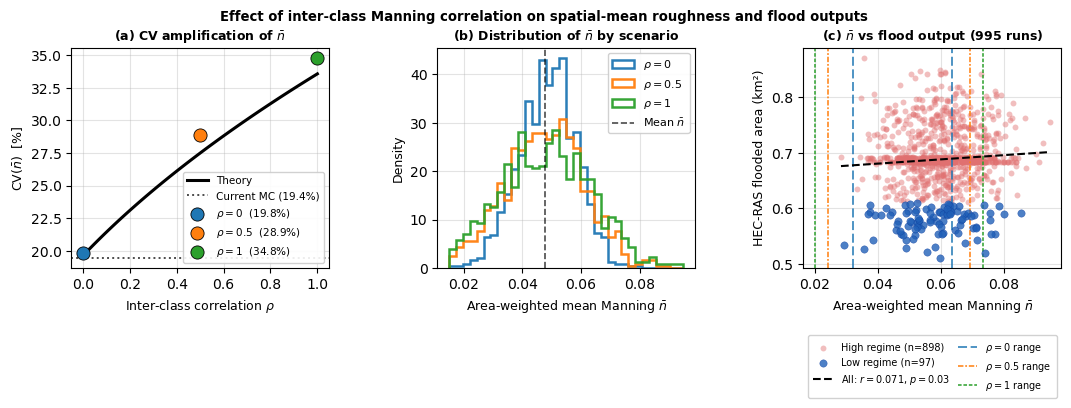

In [10]:
from sklearn.mixture import GaussianMixture

RESULTS_CSV = NB_DIR / "comparison_sfincs_hecras_clean.csv"

# ── Regime classification (GMM, consistent with nb05) ────────────────────────
df_res = pd.read_csv(RESULTS_CSV, index_col=0)   # 995 filas, ya limpias
area   = df_res["hecras_area_km2"].values
gmm    = GaussianMixture(n_components=2, random_state=42, n_init=10)
labels = gmm.fit_predict(area.reshape(-1, 1))
if gmm.means_.flatten()[0] > gmm.means_.flatten()[1]:
    labels = 1 - labels
low_mask  = labels == 0
high_mask = labels == 1
nbar_sim  = df_res["hecras_manning_mean"].values
r_all, p_all = stats.pearsonr(nbar_sim, area)
print(f"Regimes → low: {low_mask.sum()}, high: {high_mask.sum()}")

# ── Adapt n_bar to figure format ─────────────────────────────────────────────
# n_bar comes from cell 6: keys 'ρ=0 (copula)', 'ρ=0.5', 'ρ=1.0'
COLORS      = ["#1f77b4", "#ff7f0e", "#2ca02c"]
RHO_LABELS  = [r"$\rho=0$", r"$\rho=0.5$", r"$\rho=1$"]
RHO_ARRAYS  = [n_bar["ρ=0 (copula)"], n_bar["ρ=0.5"], n_bar["ρ=1.0"]]
RHO_EMP     = [0.0, 0.5, 1.0]
cv_ref_val  = 100 * n_bar["ρ=0 (ref)"].std() / n_bar["ρ=0 (ref)"].mean()

# ── Figure ───────────────────────────────────────────────────────────────────
import matplotlib.gridspec as gridspec
from scipy.stats import linregress

fig = plt.figure(figsize=(11, 3.8))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.42,
                        left=0.07, right=0.97, top=0.88, bottom=0.30)

# ── (a) CV amplification ─────────────────────────────────────────────────────
ax_a = fig.add_subplot(gs[0])
ax_a.plot(rho_vals, cv_theory, "k-", lw=2.2, label="Theory")
ax_a.axhline(cv_ref_val, color="k", ls=":", lw=1.4, alpha=0.7,
             label=f"Current MC ({cv_ref_val:.1f}%)")
for rho_num, lbl, col, arr in zip(RHO_EMP, RHO_LABELS, COLORS, RHO_ARRAYS):
    cv_emp = 100 * arr.std() / arr.mean()
    ax_a.scatter(rho_num, cv_emp, color=col, s=90, zorder=5,
                 label=f"{lbl}  ({cv_emp:.1f}%)",
                 edgecolors="k", linewidths=0.6)
ax_a.set_xlabel("Inter-class correlation " + r"$\rho$", fontsize=9)
ax_a.set_ylabel(r"CV$(\bar{n})$  [%]", fontsize=9)
ax_a.set_title(r"(a) CV amplification of $\bar{n}$", fontsize=9, fontweight="bold")
ax_a.legend(fontsize=7.5, framealpha=0.9)
ax_a.set_xlim(-0.05, 1.05)
ax_a.grid(True, alpha=0.35)

# ── (b) Distribution of n̄ ───────────────────────────────────────────────────
ax_b = fig.add_subplot(gs[1])
bins = np.linspace(0.015, 0.095, 35)
for arr, lbl, col in zip(RHO_ARRAYS, RHO_LABELS, COLORS):
    ax_b.hist(arr, bins=bins, histtype="step", linewidth=1.8,
              density=True, color=col, label=lbl, alpha=0.95)
ax_b.axvline(np.mean([a.mean() for a in RHO_ARRAYS]),
             color="k", ls="--", lw=1.2, alpha=0.7, label=r"Mean $\bar{n}$")
ax_b.set_xlabel(r"Area-weighted mean Manning $\bar{n}$", fontsize=9)
ax_b.set_ylabel("Density", fontsize=9)
ax_b.set_title(r"(b) Distribution of $\bar{n}$ by scenario",
               fontsize=9, fontweight="bold")
ax_b.legend(fontsize=8, framealpha=0.9)
ax_b.grid(True, alpha=0.35)

# ── (c) n̄ vs flooded area ───────────────────────────────────────────────────
ax_c = fig.add_subplot(gs[2])
ax_c.scatter(nbar_sim[high_mask], area[high_mask],
             s=18, alpha=0.45, color="#e07070", linewidths=0,
             label=f"High regime (n={high_mask.sum()})",
             zorder=2, rasterized=True)
ax_c.scatter(nbar_sim[low_mask], area[low_mask],
             s=28, alpha=0.80, color="#2060b8",
             linewidths=0.3, edgecolors="#1040a0",
             label=f"Low regime (n={low_mask.sum()})", zorder=3)
m, b_int, *_ = linregress(nbar_sim, area)
x_line = np.array([nbar_sim.min(), nbar_sim.max()])
ax_c.plot(x_line, m * x_line + b_int, "k--", lw=1.5,
          label=f"All: $r={r_all:.3f}$, $p={p_all:.2f}$", zorder=4)
ls_styles = [(0,(5,2)), (0,(3,1,1,1)), (0,(2,1))]
for arr, lbl, col, ls in zip(RHO_ARRAYS, RHO_LABELS, COLORS, ls_styles):
    p5, p95 = np.percentile(arr, [5, 95])
    ax_c.axvline(p5,  color=col, ls=ls, lw=1.3, alpha=0.85)
    ax_c.axvline(p95, color=col, ls=ls, lw=1.3, alpha=0.85,
                 label=f"{lbl} range")
ax_c.set_xlabel(r"Area-weighted mean Manning $\bar{n}$", fontsize=9)
ax_c.set_ylabel(r"HEC-RAS flooded area (km²)", fontsize=9)
ax_c.set_title(r"(c) $\bar{n}$ vs flood output (995 runs)",
               fontsize=9, fontweight="bold")
ax_c.grid(True, alpha=0.35)
ax_c.legend(fontsize=7, loc="upper center",
            bbox_to_anchor=(0.5, -0.28), ncol=2,
            framealpha=0.9, borderpad=0.6, columnspacing=0.8)

fig.suptitle("Effect of inter-class Manning correlation on spatial-mean "
             "roughness and flood outputs",
             fontsize=9.5, fontweight="bold", y=0.98)

for ext in ["pdf", "png"]:
    fig.savefig(FIG_DIR / f"fig_copula_analysis.{ext}",
                dpi=180, bbox_inches="tight")
plt.show()
print("Guardado en", FIG_DIR)